In [2]:
!pip install pandas numpy matplotlib seaborn ucimlrepo scikit-learn

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 880.5 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/9.9 MB 827.8 kB/s eta 0:00:11
   ---- ----------------------------------- 1.0/9.9 MB 904.8 kB/s eta 0:00:10
   ---- ----------------------------------- 1.0/9.9 MB 904.8 kB/s eta 0:00:10
   ----- ---------------------------------- 1.3/9.9 MB 913.8 kB/s eta 0:00:10
   ------ --------------------------------- 1.6/9.9 MB 914.1 kB/s eta 0:00:10
   ------- -------------------------------- 1.8/9.9 MB 953.6 kB/s eta 0:00:09
   -------- ------------------------------- 2.1/9.9 MB 996.0 kB/s eta 0:00:08
   --------- ------------------------------ 2.4/9.9 MB 1.0 MB/s eta 0:00:08
   ----------- ---------

# Ensemble

Autor: Bartosz Perz

## Zadanie 1: Salud 2030

Na potrzeby zadania potraktuj dane jako w pełni zebrane od ankietowanych.

### Wprowadzenie

Pracujesz jako Senior Data Scientist w **Secretaría de Salud de México** – meksykańskim Ministerstwie Zdrowia. Rząd Meksyku przeznaczył ogromne fundusze, angażując Cię do pomocy w wywiązaniu się z globalnych zobowiązań wobec ONZ i WHO.

Meksyk, jako sygnatariusz Agendy 2030, kładzie szczególny nacisk na **3. Cel Zrównoważonego Rozwoju (SDG 3): Dobre zdrowie i jakość życia**. Kluczowym elementem tego celu jest **Zadanie 3.4**, które zakłada ograniczenie do 2030 roku o jedną trzecią przedwczesnej umieralności z powodu chorób niezakaźnych (NCDs) poprzez zapobieganie i leczenie.

Jak jednak spełnić to wymaganie? Bierzesz na celownik otyłość – główny czynnik ryzyka wystąpienia chorób układu krążenia, cukrzycy typu 2 i nadciśnienia, które stanowią trzon problemów zdrowotnych wymienionych w SDG 3. Twoim celem jest stworzenie modelu, który na podstawie danych ankietowych zidentyfikuje osoby wymagające interwencji profilaktycznej. Aby pozyskać zbiór danych do uczenia modeli, w wybranych przychodniach przeprowadzono badanie pilotażowe.

Musisz działać precyzyjnie, ponieważ niedokładny model pominie zagrożonych pacjentów, a model zbyt "ciężki" obliczeniowo nie będzie mógł zostać wdrożony w wiejskich przychodniach o ograniczonych zasobach. W Meksyku, gdzie wskaźniki otyłości należą do najwyższych na świecie, Twoja praca nad optymalnym modelem predykcyjnym jest bezpośrednim wkładem w walkę o wydłużenie życia obywateli i redukcję obciążenia systemu ochrony zdrowia.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych dot. otyłości (UCI ID: 544)](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition).
2. **Wyucz modele klasyfikacyjne**. Wykorzystaj bibliotekę `scikit-learn` i zbadaj:

* **Pojedyncze drzewa decyzyjne** i **regresję logistyczną** – jako bazowe modele, łatwe do interpretacji przez lekarza.
* **Bagging:** `BaggingClassifier` z płytkimi drzewami, głębokimi drzewami oraz z regresją logistyczną. Przetestuj wpływ parametrów *n_estimators*, *bootstrap* i *bootstrap_features* na wyniki.
* **Boosting:** `AdaBoost` (przetestuj na płytkich drzewach i regresji logistycznej) oraz `GradientBoosting` (oparty domyślnie na drzewach). Zbadaj relację (trade-off) między parametrami *n_estimators* i *learning_rate*.
* **Stacking & Voting:** skonstruuj kolejny komitet wg własnego uznania (dobierz parametry i modele). Połącz modele o różnej architekturze, by sprawdzić, czy zespół różnych algorytmów daje lepsze efekty niż pojedynczy "ekspert".

3. **Zwaliduj modele** pod kątem wdrożenia krajowego.

* Dobierz miary **skuteczności** modelu adekwatne do problemu.
* Zwróć uwagę na **czas predykcji**.
* Zbadaj **pewność (confidence) modelu**.

4. **Zapisz wnioski dla Ministerstwa Zdrowia.**

Przy realizacji poleceń pamiętaj o charakterze zadania. Który z modeli zarekomendowałbyś do wdrożenia? Czy dokładność modelu jest jedynym wyznacznikiem jego jakości? Czy są modele, których wdrożenie byłoby stratą zasobów publicznych?

Kształt danych: (2111, 16)

Brakujące wartości:
 Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
dtype: int64


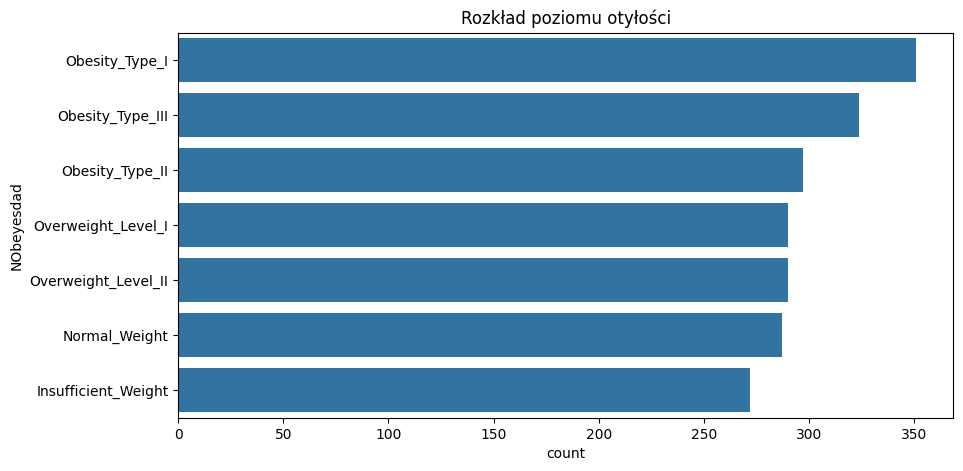

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

obesity = fetch_ucirepo(id=544)
X = obesity.data.features
y = obesity.data.targets.squeeze()

print("Kształt danych:", X.shape)
print("\nBrakujące wartości:\n", X.isnull().sum())

plt.figure(figsize=(10, 5))
sns.countplot(y=y, order=y.value_counts().index)
plt.title("Rozkład poziomu otyłości")
plt.show()

In [17]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

bagging_results_all = []

base_models = {
    "Płytkie DT": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Głębokie DT": DecisionTreeClassifier(max_depth=15, random_state=42),
    "Regresja Logistyczna": LogisticRegression(max_iter=1000, random_state=42)
}

n_estimators_list = [10, 20, 35, 50] 
bootstrap_list = [True, False]
bootstrap_features_list = [True, False]

for model_name, base_model in base_models.items():
    for n in n_estimators_list:
        for boot in bootstrap_list:
            for boot_feat in bootstrap_features_list:
                
                model = BaggingClassifier(
                    estimator=base_model,
                    n_estimators=n,
                    bootstrap=boot,
                    bootstrap_features=boot_feat,
                    random_state=42,
                    n_jobs=-1 
                )
                
                clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
                clf.fit(X_train, y_train)
                
                y_pred = clf.predict(X_test)
                acc = accuracy_score(y_test, y_pred)
                
                bagging_results_all.append({
                    "Model Bazowy": model_name,
                    "n_estimators": n,
                    "bootstrap": boot,
                    "bootstrap_features": boot_feat,
                    "Accuracy (%)": round(acc * 100, 2)
                })

df_bagging_all = pd.DataFrame(bagging_results_all)
df_bagging_all = df_bagging_all.sort_values(by="Accuracy (%)", ascending=False)

display(df_bagging_all.head(40))

,Model Bazowy,n_estimators,bootstrap,bootstrap_features,Accuracy (%)
24,Głębokie DT,35,True,True,94.95
29,Głębokie DT,50,True,False,94.48
21,Głębokie DT,20,True,False,94.32
17,Głębokie DT,10,True,False,94.32
28,Głębokie DT,50,True,True,94.32
25,Głębokie DT,35,True,False,94.32
20,Głębokie DT,20,True,True,94.01
30,Głębokie DT,50,False,True,93.38
26,Głębokie DT,35,False,True,92.90
22,Głębokie DT,20,False,True,92.90


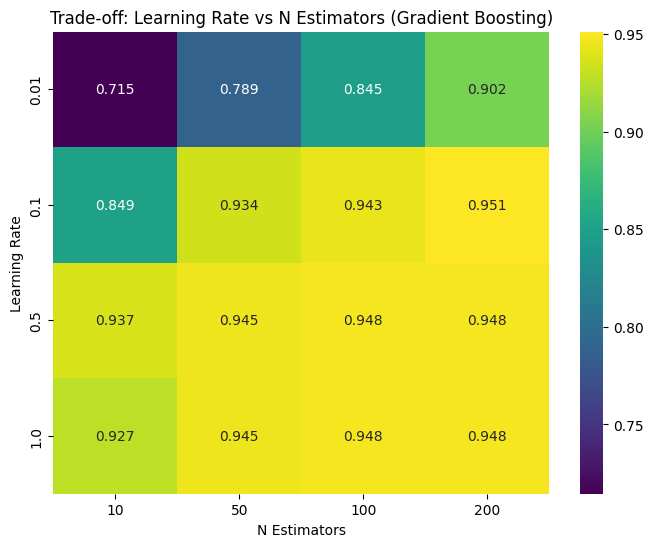

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns

boosting_results = []

learning_rates = [0.01, 0.1, 0.5, 1.0]
estimators_counts = [10, 50, 100, 200]

for lr in learning_rates:
    for n in estimators_counts:
        
        model = GradientBoostingClassifier(n_estimators=n, learning_rate=lr, random_state=42)
        
        clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
        clf.fit(X_train, y_train)
        
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        
        boosting_results.append({
            "Learning Rate": lr,
            "N Estimators": n,
            "Accuracy": acc
        })

df_boost = pd.DataFrame(boosting_results)
pivot_table = df_boost.pivot(index='Learning Rate', columns='N Estimators', values='Accuracy')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
plt.title("Trade-off: Learning Rate vs N Estimators (Gradient Boosting)")
plt.show()

In [18]:
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (BaggingClassifier, AdaBoostClassifier, 
                              GradientBoostingClassifier, StackingClassifier, VotingClassifier)
from sklearn.metrics import accuracy_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

models = {
    "Płytkie Drzewo (DT)": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Głębokie Drzewo (DT)": DecisionTreeClassifier(max_depth=15, random_state=42),
    "Regresja Logistyczna (LR)": LogisticRegression(max_iter=1000, random_state=42),
    
    "Bagging (Płytkie DT)": BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=35, bootstrap=True, bootstrap_features=True, random_state=42),
    "Bagging (Głębokie DT)": BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=15), n_estimators=35, bootstrap_features=True, bootstrap=True, random_state=42),
    "Bagging (LR)": BaggingClassifier(estimator=LogisticRegression(max_iter=1000), n_estimators=10, bootstrap_features=False, bootstrap=False, random_state=42),
    
    "AdaBoost (Płytkie DT)": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=50, random_state=42),
    "AdaBoost (LR)": AdaBoostClassifier(estimator=LogisticRegression(max_iter=1000, random_state=42), n_estimators=50, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=10, learning_rate=0.5, random_state=42),
    
    "Stacking (DT, LR -> GB)": StackingClassifier(
        estimators=[
            ('rf', DecisionTreeClassifier(max_depth=10)),
            ('lr', LogisticRegression(max_iter=1000))
        ],
        final_estimator=GradientBoostingClassifier(n_estimators=20)
    ),
    
    "Voting Soft (DT + LR)": VotingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(max_depth=10, random_state=42)),
            ('lr', LogisticRegression(max_iter=1000, random_state=42))
        ],
        voting='soft' 
    )
}

results = []

for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    
    clf.fit(X_train, y_train)
    
    start_time = time.perf_counter()
    y_pred = clf.predict(X_test)
    end_time = time.perf_counter()
    inference_time = (end_time - start_time) * 1000
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    probabilities = clf.predict_proba(X_test)
    confidence = np.mean(np.max(probabilities, axis=1))
    
    results.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "F1 Score (%)": round(f1 * 100, 2),
        "Confidence (%)": round(confidence * 100, 2),
        "Time (ms)": round(inference_time, 2)
    })

results_df = pd.DataFrame(results)
display(results_df)

C:\Users\HP\AppData\Local\Temp\ipykernel_42988\861363424.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns


,Model,Accuracy (%),F1 Score (%),Confidence (%),Time (ms)
0,Płytkie Drzewo (DT),63.88,62.25,66.41,10.53
1,Głębokie Drzewo (DT),90.69,90.62,100.00,10.23
2,Regresja Logistyczna (LR),87.22,87.05,75.53,10.38
3,Bagging (Płytkie DT),72.56,70.83,55.37,17.94
4,Bagging (Głębokie DT),94.95,94.96,82.08,17.52
5,Bagging (LR),87.22,87.05,75.53,14.32
6,AdaBoost (Płytkie DT),90.69,90.77,15.06,23.74
7,AdaBoost (LR),46.53,45.77,14.73,26.80
8,Gradient Boosting,93.69,93.69,90.57,9.85
9,"Stacking (DT, LR -> GB)",92.90,92.82,91.41,12.31


## Zadanie 2: Grzybobranie

### Wprowadzenie

Mieszkasz w "Warszawce". Ostatnio całe miasto opanował nowy trend – grzybobranie! Czy wiedziałeś, że grzybów nie trzeba kupować w sklepie? Rosną w lesie, zupełnie za darmo i E-KO-LO-GICZ-NIE.

Postanawiasz wybrać się do "mało znanego" miejsca – lasu pod Konstancinem-Jeziorną. Niestety, na miejscu okazuje się, że o grzybach nie masz zielonego pojęcia, a odróżnienie borowika od muchomora stanowi dla Ciebie ogromne wyzwanie. Już masz się poddać, ale nagle słyszysz za sobą podniesiony głos:

– Radziu, nie mów do mnie teraz!

Obracasz się i widzisz miło wyglądającą rodzinkę.

<img src="img.jpg" width="400" height="400" />

(Źródło: <a href="https://www.instagram.com/p/COLCA3RHoni/">instagram m_rozenek</a>)

Skądś ich kojarzysz (może z *morning matcha rave*?), ale nie to jest teraz najważniejsze. Widzisz, że próbują rozszyfrować **ZAAWANSOWANY ATLAS GRZYBÓW**. Postanawiasz dołączyć do zadania, ale szybko okazuje się, że rozumiesz z niego tyle co nic. Zamiast zdjęć i opisów, atlas zawiera wyłącznie tabele przedstawiające cechy grzybów. Sprawdzanie całej tabeli w poszukiwaniu odpowiedniego dopasowania do zaobserwowanych parametrów okazu od razu wydaje Ci się marnowaniem czasu. Wykorzystujesz więc wiedzę nabytą na zajęciach ze Sztucznej Inteligencji i postanawiasz stworzyć model uczenia maszynowego klasyfikujący grzyby.

Pamiętaj – błąd algorytmu oznacza poważne zatrucie. Chociaż masz dostęp do potężnych narzędzi, bateria w Twoim telefonie jest na wyczerpaniu, a każda sekunda pracy procesora jest na wagę złota. Musisz zdecydować, jaki model będzie adekwatny do zadania – na tyle precyzyjny, by przeżyć, a zarazem wystarczająco "lekki", by zadziałał w lesie.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych o grzybach (UCI ID: 73)](https://archive.ics.uci.edu/dataset/73/mushroom).
2. Według własnego uznania **wybierz modele** i **wyucz** je. Wykorzystaj zdobytą dotychczas wiedzę. Przynajmniej jednym z testowanych modeli powinien być model zespołowy (ensemble).
3. **Zwaliduj wyuczone modele**. Pamiętaj, że pomyłka może skończyć się zatruciem, więc warto byłoby móc zinterpretować i zrozumieć decyzje modelu.
4. **Zapisz wnioski**.

Przy realizacji poleceń pamiętaj o specyficznym charakterze i ograniczeniach zadania.

In [ ]:
mushroom = fetch_ucirepo(id=73)
X_m = mushroom.data.features
y_m = mushroom.data.targets.squeeze()

X_m = X_m.fillna('Missing')

print("Rozkład klas (jadalne vs trujące):")
print(y_m.value_counts())

Rozkład klas (jadalne vs trujące):
poisonous
e    4208
p    3916
Name: count, dtype: int64


Czas predykcji Drzewa: 32.05 ms
Czas predykcji Random Forest: 86.73 ms


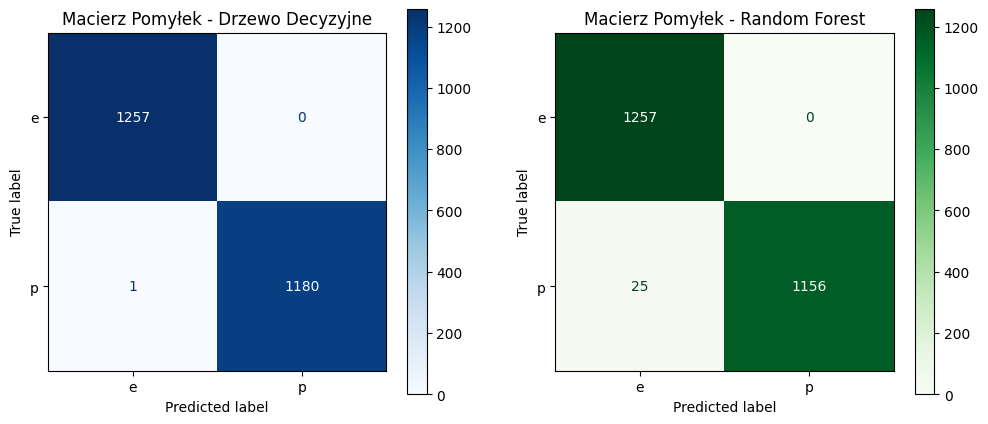

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_m_encoded = encoder.fit_transform(X_m)

X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(X_m_encoded, y_m, test_size=0.3, random_state=42)

dt_mushroom = DecisionTreeClassifier(max_depth=5, random_state=42)

start_time = time.perf_counter()
dt_mushroom.fit(X_m_train, y_m_train)
y_m_pred_dt = dt_mushroom.predict(X_m_test)
dt_time = (time.perf_counter() - start_time) * 1000

rf_mushroom = RandomForestClassifier(n_estimators=15, max_depth=5, random_state=42)

start_time = time.perf_counter()
rf_mushroom.fit(X_m_train, y_m_train)
y_m_pred_rf = rf_mushroom.predict(X_m_test)
rf_time = (time.perf_counter() - start_time) * 1000

print(f"Czas predykcji Drzewa: {dt_time:.2f} ms")
print(f"Czas predykcji Random Forest: {rf_time:.2f} ms")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_m_test, y_m_pred_dt, ax=axes[0], cmap='Blues')
axes[0].set_title('Macierz Pomyłek - Drzewo Decyzyjne')

ConfusionMatrixDisplay.from_predictions(y_m_test, y_m_pred_rf, ax=axes[1], cmap='Greens')
axes[1].set_title('Macierz Pomyłek - Random Forest')

plt.show()